In [2]:
#Import thư viện
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

In [3]:
file_path = "../datasets/cleaned_data/products_clean.csv"

products = pd.read_csv(file_path)
products.head()

,id,sku,name,seller_product_id,seller_id,tracking_info_amplitude,inventory_status,inventory_type,data_version,day_ago_created,...,badges_new_has_video_badge,badges_new_has_authentic_badge,badges_new_has_variant_count_badge,badges_new_has_delivery_badge,badges_v3_has_video_badge,badges_v3_has_authentic_badge,badges_v3_has_variant_count_badge,badges_v3_has_delivery_badge,log_quantity_sold,best_seller
0,54645,6508148796624,Tai nghe chụp tai Logitech H150 - 2 jack 3.5mm...,1095356,915,is_authentic:True; is_freeship_xtra:True; is_h...,available,backorder,3300,4775,...,False,True,True,True,False,False,False,False,4.574711,False
1,54665,5007102619128,Chuột không dây Logitech M185 - Hàng chính hãn...,54673,1,is_authentic:True; is_freeship_xtra:False; is_...,available,backorder,3300,4774,...,True,True,True,True,False,False,False,False,8.832734,True
2,122012,6805279483134,Bộ Bàn Phím Và Chuột Không Dây Logitech MK240 ...,122016,1,is_authentic:True; is_freeship_xtra:False; is_...,available,instock,3300,4081,...,True,True,True,True,False,False,False,False,7.491645,True
3,227386,1446930336854,Pin Sạc Dự Phòng Anker PowerCore 20100mAh - A1271,227388,1,is_authentic:True; is_freeship_xtra:False; is_...,available,backorder,3300,3527,...,False,True,True,True,False,False,False,False,7.344073,True
4,299461,3057399746627,Chuột Không Dây Logitech M331 Silent,49019988,27572,is_authentic:True; is_freeship_xtra:True; is_h...,available,backorder,3300,3337,...,False,True,True,True,False,False,False,False,9.221577,True


In [4]:
# 1. Phân tích phân bổ GMV proxy theo category
gmv_table = (
    products[products["price"].notna() & products["quantity_sold"].notna()]
    .assign(gmv_proxy=lambda x: x["price"].astype("int64") * x["quantity_sold"])
    .groupby("category")["gmv_proxy"]
    .sum()
    .reset_index()
)

total_gmv = gmv_table["gmv_proxy"].sum()

gmv_table["gmv_pct"] = (gmv_table["gmv_proxy"] / total_gmv * 100).round(2)
gmv_table = gmv_table.sort_values("gmv_proxy", ascending=False).reset_index(drop=True)
gmv_table["cumulative_gmv_pct"] = (gmv_table["gmv_proxy"].cumsum() / total_gmv * 100).round(2)

# 2. So sánh mức giảm giá trung bình theo category
discount_category = (
    products
    .groupby("category")
    .agg(
        product_count=("category", "count"),
        avg_discount_rate=("discount_rate", "mean")
    )
)

discount_category = (
    discount_category[discount_category["product_count"] >= 30]
    .round({"avg_discount_rate": 4})
    .sort_values("avg_discount_rate", ascending=False)
)
discount_category = discount_category.reset_index()

# 3. Best Seller and Non Best Seller Analysis
import math

top_n = math.ceil(len(products) * 0.1)

products_sorted = products.sort_values("quantity_sold", ascending=False).copy()
products_sorted["seller_group"] = "Non Best Seller"
products_sorted.iloc[:top_n, products_sorted.columns.get_loc("seller_group")] = "Best Seller"

best_seller_analysis = (
    products_sorted
    .groupby("seller_group")
    .agg(
        product_count=("seller_group", "count"),
        avg_price=("price", "mean"),
        avg_discount=("discount_rate", "mean"),
        avg_rating=("rating_average", "mean"),
        avg_reviews=("reviews_count", "mean")
    )
    .round({
        "avg_price": 2,
        "avg_discount": 4,
        "avg_rating": 2,
        "avg_reviews": 2
    })
    .reset_index()
)

# 4. Phân nhóm theo mức rating
def rating_bin(x):
    if x >= 4.5:
        return "Excellent (>=4.5)"
    elif x >= 4:
        return "Good (4-4.49)"
    elif x >= 3:
        return "Average (3-3.99)"
    else:
        return "Low (<3)"

products["rating_bin"] = products["rating_average"].apply(rating_bin)

rating_analysis = (
    products
    .groupby("rating_bin")
    .agg(
        product_count=("rating_bin", "count"),
        avg_quantity_sold=("quantity_sold", "mean"),
        avg_reviews=("reviews_count", "mean"),
        avg_price=("price", "mean")
    )
    .round({
        "avg_quantity_sold": 0,
        "avg_reviews": 0,
        "avg_price": 2
    })
    .sort_values("avg_quantity_sold", ascending=False)
    .reset_index()
)


Top 6 categories account for ~80% of total GMV.


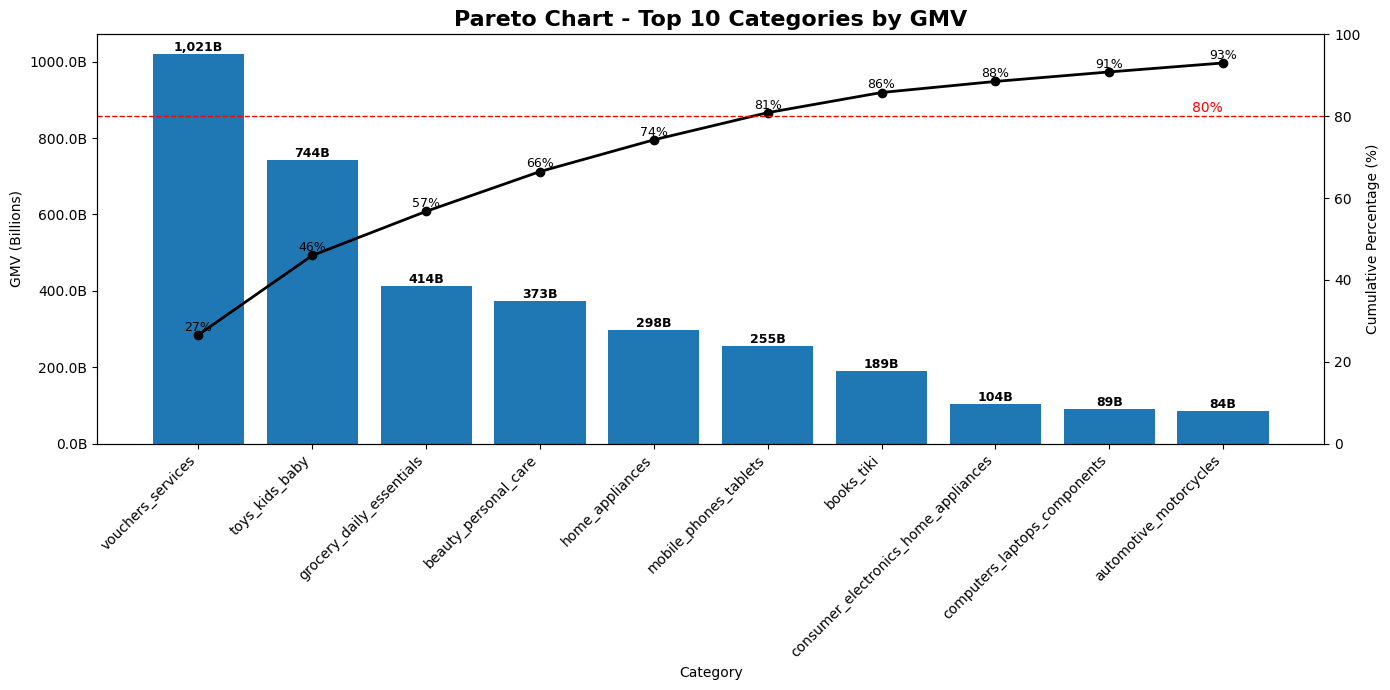

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# ==============================
# 1. GMV theo category
gmv_table = (
    products[products["price"].notna() & products["quantity_sold"].notna()]
    .assign(gmv_proxy=lambda x: x["price"].astype("int64") * x["quantity_sold"])
    .groupby("category")["gmv_proxy"]
    .sum()
    .reset_index()
)

# ==============================
# 2. Sort giảm dần
gmv_category = gmv_table.sort_values("gmv_proxy", ascending=False).reset_index(drop=True)

# ==============================
# 3. Tính cumulative % trên TOÀN BỘ dataset
total_gmv = gmv_category["gmv_proxy"].sum()
gmv_category["cum_pct"] = gmv_category["gmv_proxy"].cumsum() / total_gmv * 100

# ==============================
# 4. Lấy TOP 10 để vẽ
top_n = 10
gmv_top10 = gmv_category.head(top_n).copy()

# ==============================
# 5. Vẽ Pareto chart
fig, ax1 = plt.subplots(figsize=(14, 7))

# Bar chart (GMV)
bars = ax1.bar(gmv_top10["category"], gmv_top10["gmv_proxy"])
# Hiển thị value trên mỗi bar
for bar in bars:
    height = bar.get_height()

    ax1.text(
        bar.get_x() + bar.get_width() / 2,  # vị trí giữa bar
        height,                              # đỉnh bar
        f'{height/1e9:,.0f}B',               # format billions
        ha='center',
        va='bottom',
        fontsize=9,
        fontweight='bold'
    )

ax1.set_title("Pareto Chart - Top 10 Categories by GMV", fontsize=16, fontweight="bold")
ax1.set_xlabel("Category")
ax1.set_ylabel("GMV (Billions)")

# Format trục Y cho dễ đọc (đổi sang billions)
ax1.get_yaxis().set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'{x/1e9:.1f}B')
)

# Xoay label
plt.setp(ax1.get_xticklabels(), rotation=45, ha="right")

# ==============================
# 6. Line chart (% tích lũy)
ax2 = ax1.twinx()

ax2.plot(
    gmv_top10["category"],
    gmv_top10["cum_pct"],
    color="black",
    marker="o",
    linewidth=2
)

ax2.set_ylabel("Cumulative Percentage (%)")
ax2.set_ylim(0, 100)

# Label %
for i, pct in enumerate(gmv_top10["cum_pct"]):
    ax2.text(i, pct + 1, f"{pct:.0f}%", ha="center", fontsize=9)

# ==============================
# 7. Đường 80% (Pareto rule)
ax2.axhline(80, color="red", linestyle="--", linewidth=1)

ax2.text(
    len(gmv_top10) - 1,
    81,
    "80%",
    ha="right",
    fontsize=10,
    color="red"
)

# ==============================
# 8. Insight: bao nhiêu category = 80%
num_categories_80 = (gmv_category["cum_pct"] <= 80).sum() + 1

print(f"Top {num_categories_80} categories account for ~80% of total GMV.")

# ==============================
# 9. Show
plt.tight_layout()
plt.show()

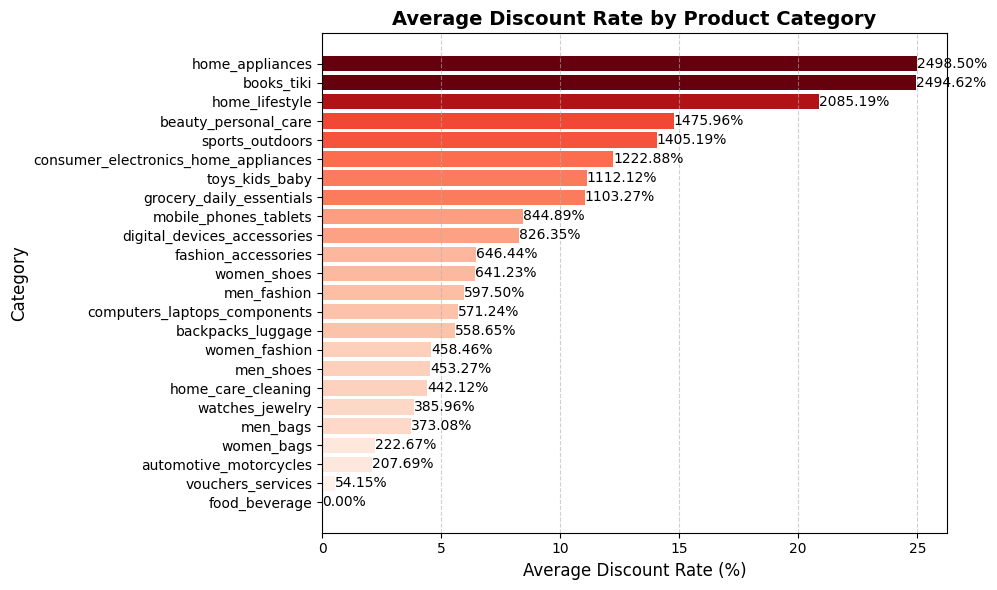

In [11]:
#2. Vẽ biểu đồ so sánh mức giảm giá trung bình theo category
plt.figure(figsize=(10,6))

# tạo màu gradient
colors = plt.cm.Reds(
    discount_category["avg_discount_rate"] / discount_category["avg_discount_rate"].max()
)

bars = plt.barh(
    discount_category["category"],
    discount_category["avg_discount_rate"],
    color=colors
)

plt.xlabel("Average Discount Rate (%)", fontsize=12)
plt.ylabel("Category", fontsize=12)

plt.title(
    "Average Discount Rate by Product Category",
    fontsize=14,
    fontweight="bold"
)

plt.grid(axis="x", linestyle="--", alpha=0.6)

# hiển thị số %
for bar in bars:
    width = bar.get_width()
    plt.text(
        width,
        bar.get_y() + bar.get_height()/2,
        f"{width:.2%}",
        va="center",
        fontsize=10
    )

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

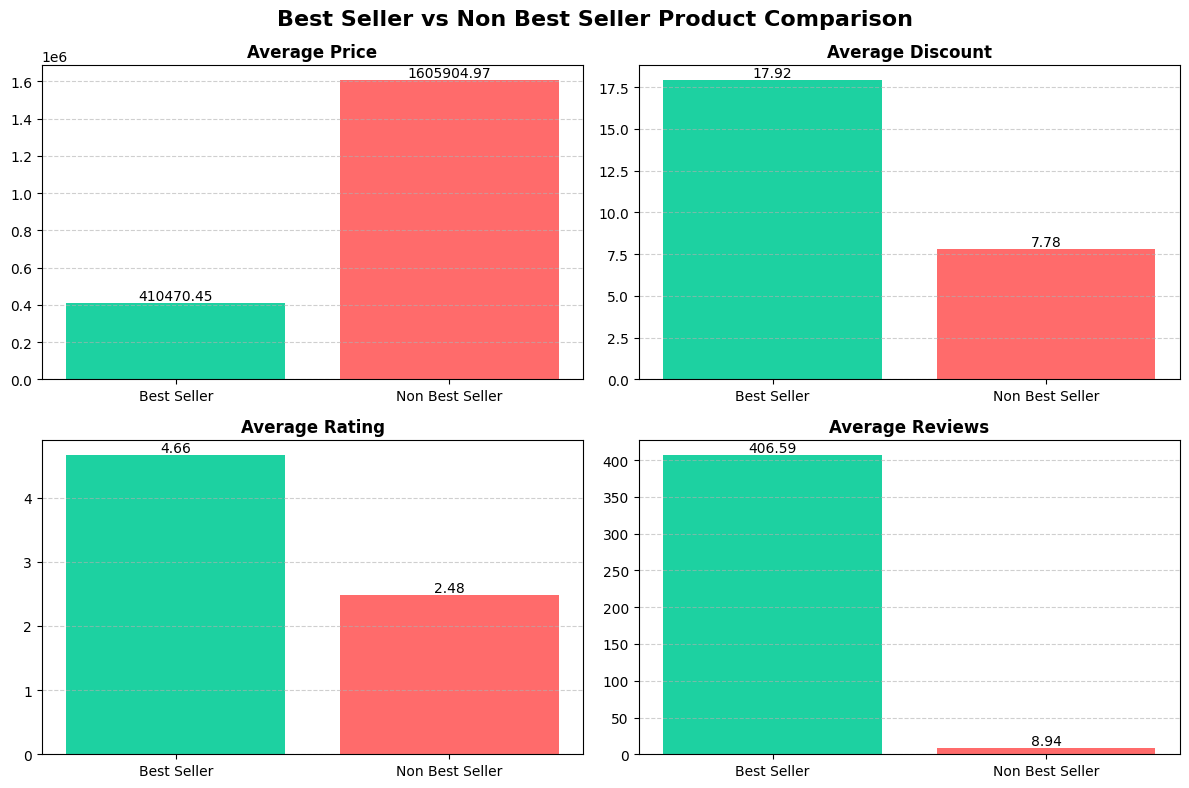

In [12]:
#3. Vẽ biểu đồ so sánh Best Seller vs Non Best Seller
metrics = ["avg_price","avg_discount","avg_rating","avg_reviews"]

titles = [
    "Average Price",
    "Average Discount",
    "Average Rating",
    "Average Reviews"
]

colors = ["#1dd1a1", "#ff6b6b"]

fig, axes = plt.subplots(2,2, figsize=(12,8))
axes = axes.flatten()

for i, metric in enumerate(metrics):

    bars = axes[i].bar(
        best_seller_analysis["seller_group"],
        best_seller_analysis[metric],
        color=colors
    )

    axes[i].set_title(titles[i], fontsize=12, fontweight="bold")
    axes[i].grid(axis="y", linestyle="--", alpha=0.6)

    # hiển thị số trên cột
    for bar in bars:
        yval = bar.get_height()
        axes[i].text(
            bar.get_x() + bar.get_width()/2,
            yval,
            f"{yval:.2f}",
            ha="center",
            va="bottom",
            fontsize=10
        )

fig.suptitle(
    "Best Seller vs Non Best Seller Product Comparison",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

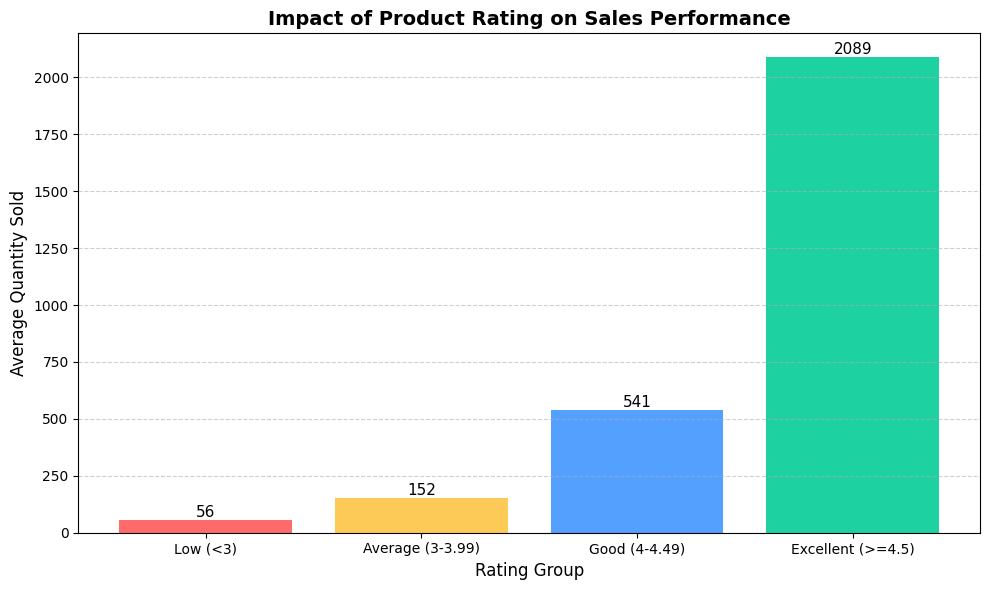

In [13]:
#4. Vẽ biểu đồ so sánh mức độ ảnh hưởng của rating đến hiệu suất bán hàng
# Sắp xếp lại thứ tự rating
order = ["Low (<3)", "Average (3-3.99)", "Good (4-4.49)", "Excellent (>=4.5)"]

rating_analysis = rating_analysis.set_index("rating_bin").loc[order].reset_index()

plt.figure(figsize=(10,6))

bars = plt.bar(
    rating_analysis["rating_bin"],
    rating_analysis["avg_quantity_sold"],
    color=["#ff6b6b","#feca57","#54a0ff","#1dd1a1"]
)

plt.xlabel("Rating Group", fontsize=12)
plt.ylabel("Average Quantity Sold", fontsize=12)

plt.title(
    "Impact of Product Rating on Sales Performance",
    fontsize=14,
    fontweight="bold"
)

plt.grid(axis="y", linestyle="--", alpha=0.6)

# Hiển thị số trên đầu cột
for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        yval,
        f"{yval:.0f}",
        ha="center",
        va="bottom",
        fontsize=11
    )

plt.tight_layout()
plt.show()